# Análisis exploratorio de datos (EDA) — RE/MAX CABA

Este notebook explora la base analítica generada en `03_features_kpis.ipynb` para responder las preguntas descriptivas y diagnósticas del proyecto y obtener evidencia preliminar sobre las hipótesis. Cada sección parte de una pregunta del README, presenta la evidencia (estadísticos, gráficos y tests) y cierra con una conclusión.

**Entrada:** `data/processed/remax_deptos_features.csv` (9.499 departamentos usados, 99 variables).

**Dependencias:** `src/eda.py` (estadísticos y tests).

**Hipótesis:**

- **H1. Descuento por condición:** los departamentos que necesitan obra tienen un USD/m² menor que los reciclados, aun dentro de un mismo segmento.
- **H2. Dispersión condicional:** la dispersión del USD/m² dentro de estratos homogéneos difiere entre zonas y se asocia con oportunidades de subvaluación, siempre que no se explique por errores de carga.
- **H3. Oportunidades de flipping:** en una parte de las unidades que necesitan obra, el valor post-obra supera el precio de compra más los costos de la operación.

Los tests de esta etapa son **evidencia preliminar**. La validación formal de las hipótesis corresponde a la siguiente pre-entrega. Se usa un nivel de significación del 5%. Como las variables de precio son asimétricas (ver sección 2), se usan tests no paramétricos, que comparan distribuciones y medianas sin suponer normalidad.

In [ ]:
# 1. ENTORNO, IMPORTS Y CARGA

import os

REPO_URL = "https://github.com/DTosoratti/tp-analitica-descriptiva-real-estate.git"
REPO_DIR = "/content/tp-analitica-descriptiva-real-estate"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    !git -C {REPO_DIR} pull

%cd {REPO_DIR}

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.eda import (resumen_robusto, dispersion_por_grupo, test_mann_whitney,
                     test_kruskal, premio_por_variable)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.options.display.float_format = "{:,.2f}".format

RUTA_FEATURES = Path("data/processed/remax_deptos_features.csv")
df = pd.read_csv(RUTA_FEATURES)

# Precio relativo al benchmark: cuánto más caro (+) o más barato (−) que sus comparables
df["Precio_Relativo_pct"] = -df["Gap_Subvaluacion_pct"]

print("Dimensiones:", df.shape)
print("Fecha de corte de la extracción: 26/09/2026 (aproximada)")

Cloning into 'tp-analitica-descriptiva-real-estate'...
remote: Enumerating objects: 275, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 275 (delta 59), reused 15 (delta 15), pack-reused 159 (from 1)
Receiving objects: 100% (275/275), 39.02 MiB | 18.09 MiB/s, done.
Resolving deltas: 100% (122/122), done.
/content/tp-analitica-descriptiva-real-estate
Dimensiones: (9499, 100)
Fecha de corte de la extracción: 26/09/2026 (aproximada)


## 2. Panorama general del mercado

**Pregunta:** ¿cómo se distribuyen el precio, la superficie y el precio por m² de la oferta de departamentos usados?

Se calculan estadísticos de resumen robustos (mediana y cuantiles, además de media y desvío) y se analiza la forma de la distribución del precio por m² en escala original y logarítmica.

In [ ]:
# 2.1 ESTADÍSTICOS DE RESUMEN

variables_numericas = ["Precio_Valor", "Superficie_Homogeneizada_m2", "USD_m2_Homogeneizado",
                       "Ambientes", "Antiguedad", "Expensas_Imputadas"]
display(resumen_robusto(df, variables_numericas))

,N,Media,Mediana,Desvío,Asimetría,Curtosis,P05,P25,P75,P95
Variable,,,,,,,,,,
Precio_Valor,9499,"163,414.31","120,000.00","175,699.16",9.89,223.34,"53,000.00","80,950.00","182,000.00","400,000.00"
Superficie_Homogeneizada_m2,9499,68.69,56.93,44.26,2.95,15.57,28.30,40.81,81.00,152.14
USD_m2_Homogeneizado,9499,"2,307.54","2,183.13",885.10,1.98,12.69,"1,199.97","1,722.12","2,711.07","3,847.80"
Ambientes,9499,2.69,3.00,1.17,0.72,2.27,1.00,2.00,3.00,4.00
Antiguedad,9177,38.30,45.00,23.08,-0.03,-0.55,1.00,16.00,56.00,71.00
Expensas_Imputadas,9499,"260,235.31","200,000.00","220,495.42",3.90,26.11,"80,000.00","140,000.00","300,000.00","650,000.00"


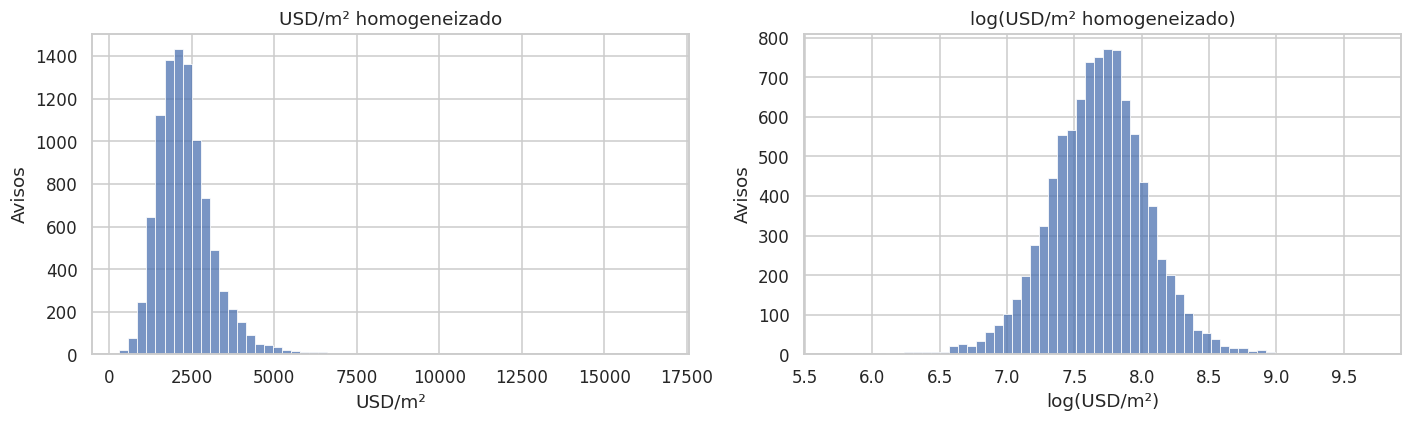

In [ ]:
# 2.2 DISTRIBUCIÓN DEL PRECIO POR M²

fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["USD_m2_Homogeneizado"], bins=60, ax=ejes[0])
ejes[0].set(title="USD/m² homogeneizado", xlabel="USD/m²", ylabel="Avisos")
sns.histplot(np.log(df["USD_m2_Homogeneizado"]), bins=60, ax=ejes[1])
ejes[1].set(title="log(USD/m² homogeneizado)", xlabel="log(USD/m²)", ylabel="Avisos")
plt.tight_layout()
plt.show()

**Resultado.** El departamento usado típico se publica a USD 120.000 (mediana), con 57 m² homogeneizados y un precio de USD 2.183 por m². Las variables de precio y superficie son marcadamente asimétricas a la derecha: el precio total tiene una asimetría de 9,9, y la media (USD 163.414) supera ampliamente a la mediana, por el peso de un segmento reducido de unidades de alto valor. El precio por m² también es asimétrico (asimetría de 2,0 y curtosis de 12,7), mientras que su logaritmo tiene una forma mucho más simétrica. Por eso, en el resto del análisis se usan la mediana y los cuantiles como medidas de referencia, y tests no paramétricos para las comparaciones.

El stock es antiguo: la mitad de los edificios tiene más de 45 años, y solo el 25% tiene menos de 16. Las expensas imputadas tienen una mediana de ARS 200.000 mensuales.

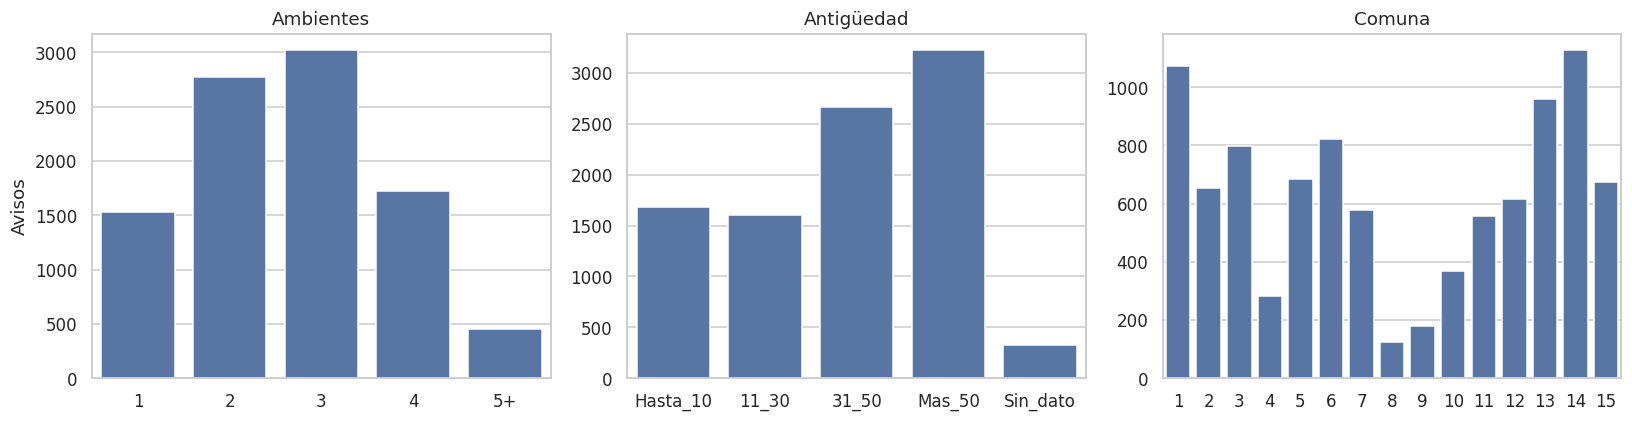

In [ ]:
# 2.3 COMPOSICIÓN DE LA OFERTA

fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
orden_amb = ["1", "2", "3", "4", "5+"]
sns.countplot(data=df, x="Ambientes_Grupo", order=orden_amb, ax=ejes[0])
ejes[0].set(title="Ambientes", xlabel="", ylabel="Avisos")
orden_ant = ["Hasta_10", "11_30", "31_50", "Mas_50", "Sin_dato"]
sns.countplot(data=df, x="Banda_Antiguedad", order=orden_ant, ax=ejes[1])
ejes[1].set(title="Antigüedad", xlabel="", ylabel="")
sns.countplot(data=df, x="Comuna", ax=ejes[2])
ejes[2].set(title="Comuna", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

**Resultado.** La oferta se concentra en unidades de 2 y 3 ambientes, que representan más del 60% de los avisos, mientras que las de 5 o más ambientes son menos del 5%. Por antigüedad, predominan los edificios de más de 30 años. Geográficamente, la oferta se concentra en las comunas 14 (Palermo), 1 (centro y Puerto Madero) y 13 (Belgrano, Núñez y Colegiales), mientras que las comunas del sur, como la 8, tienen muy pocos avisos. Esa concentración condiciona la precisión del benchmark: en las zonas con poca oferta, los grupos de comparables se amplían a la comuna con más frecuencia.

## 3. Precio por m² según ubicación, tamaño y antigüedad

**Pregunta descriptiva 1:** ¿cuál es el USD/m² mediano y su dispersión por barrio, y cómo varía según superficie, ambientes y antigüedad?

Para cada barrio con al menos 30 avisos se informan la mediana, los cuartiles y la dispersión relativa (rango intercuartílico sobre la mediana), que permite comparar la variabilidad de barrios con niveles de precio distintos.

Barrios con al menos 30 avisos: 43


,N,Mediana,P25,P75,IQR,Dispersion_relativa
Barrio_Oficial,,,,,,
Puerto Madero,43,"5,110.48","4,367.86","5,700.32","1,332.47",0.26
Nuñez,265,"2,903.54","2,452.83","3,459.38","1,006.55",0.35
Palermo,1127,"2,851.85","2,397.42","3,422.45","1,025.04",0.36
Villa Ortuzar,106,"2,751.24","2,285.74","3,645.62","1,359.88",0.49
Belgrano,507,"2,724.00","2,361.92","3,288.28",926.36,0.34
Villa Urquiza,340,"2,566.79","2,253.32","3,072.76",819.44,0.32
Saavedra,152,"2,544.33","2,214.24","3,021.24",807.00,0.32
Coghlan,64,"2,539.74","2,242.52","2,839.56",597.04,0.23
Colegiales,187,"2,537.43","2,255.38","3,036.04",780.65,0.31


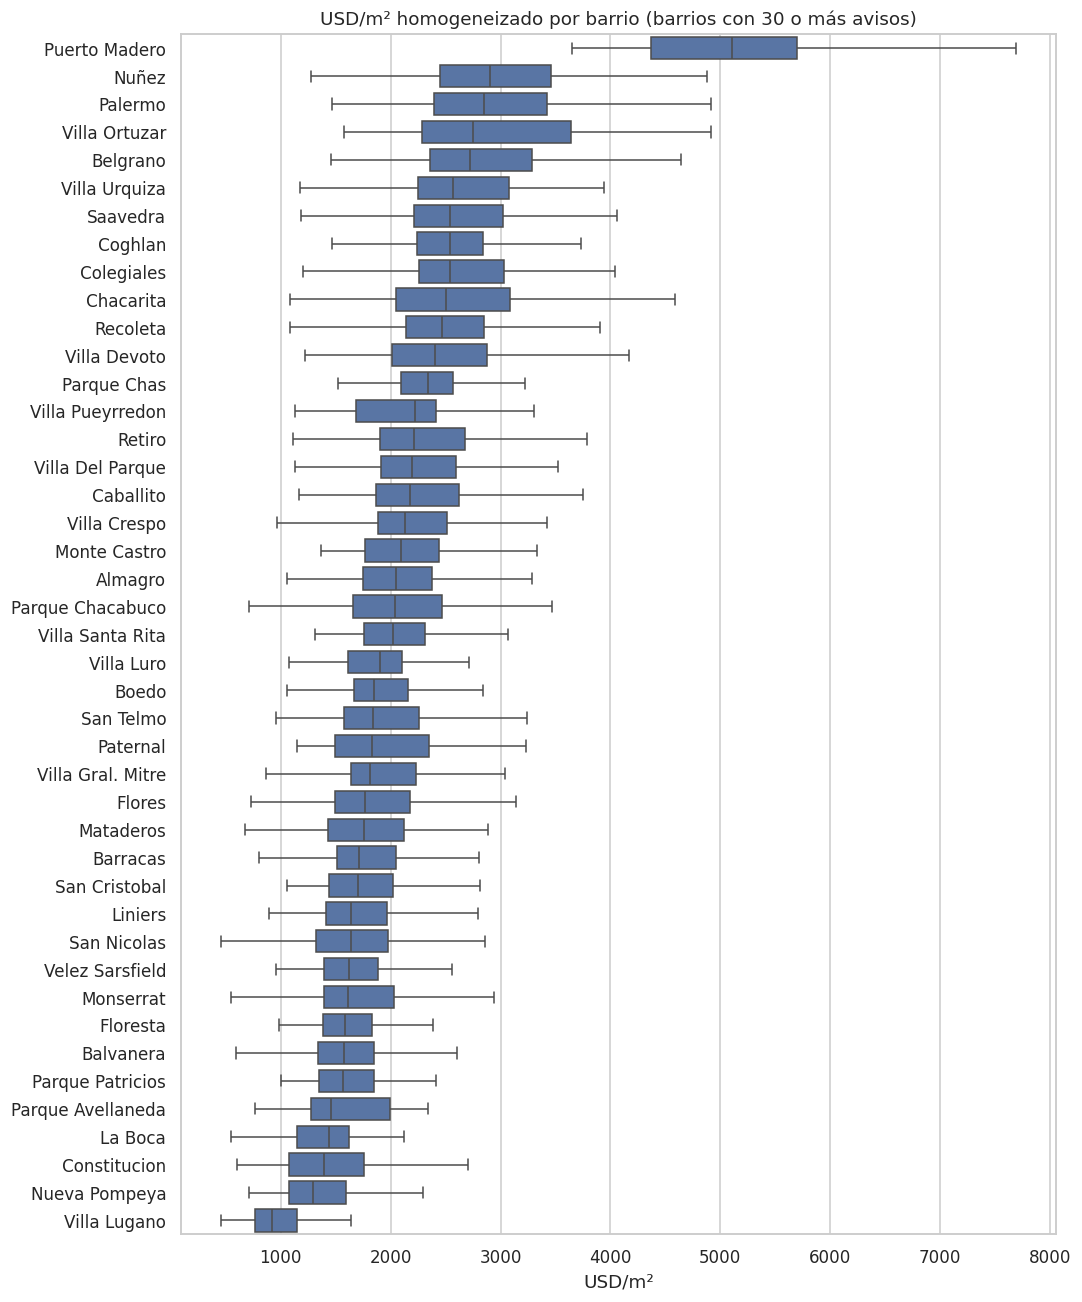

In [ ]:
# 3.1 USD/M² POR BARRIO

tabla_barrios = dispersion_por_grupo(df, "Barrio_Oficial", "USD_m2_Homogeneizado", min_n=30)
print(f"Barrios con al menos 30 avisos: {len(tabla_barrios)}")
display(tabla_barrios)

orden = tabla_barrios.index
fig, ax = plt.subplots(figsize=(10, 12))
sns.boxplot(data=df[df["Barrio_Oficial"].isin(orden)], y="Barrio_Oficial",
            x="USD_m2_Homogeneizado", order=orden, showfliers=False, ax=ax)
ax.set(title="USD/m² homogeneizado por barrio (barrios con 30 o más avisos)",
       xlabel="USD/m²", ylabel="")
plt.tight_layout()
plt.show()

**Resultado.** El precio por m² varía fuertemente según la ubicación. Entre los 43 barrios con al menos 30 avisos, la mediana va de USD 917 en Villa Lugano a USD 5.110 en Puerto Madero: una diferencia de más de cinco veces. Después de Puerto Madero, los valores más altos se ubican en el corredor norte (Núñez, Palermo, Belgrano, Villa Urquiza y Saavedra, entre USD 2.540 y 2.900), y los más bajos en el sur (Nueva Pompeya, Constitución, La Boca, Parque Avellaneda y Parque Patricios, entre USD 1.300 y 1.560).

La dispersión relativa dentro de cada barrio (rango intercuartílico sobre la mediana) también difiere: va de 0,20 en Parque Chas a casi 0,50 en Villa Ortúzar, Constitución y Parque Avellaneda. Esto confirma que el barrio es la variable principal para construir los grupos de comparables, y que el promedio de la ciudad no es una referencia útil para valuar una propiedad.

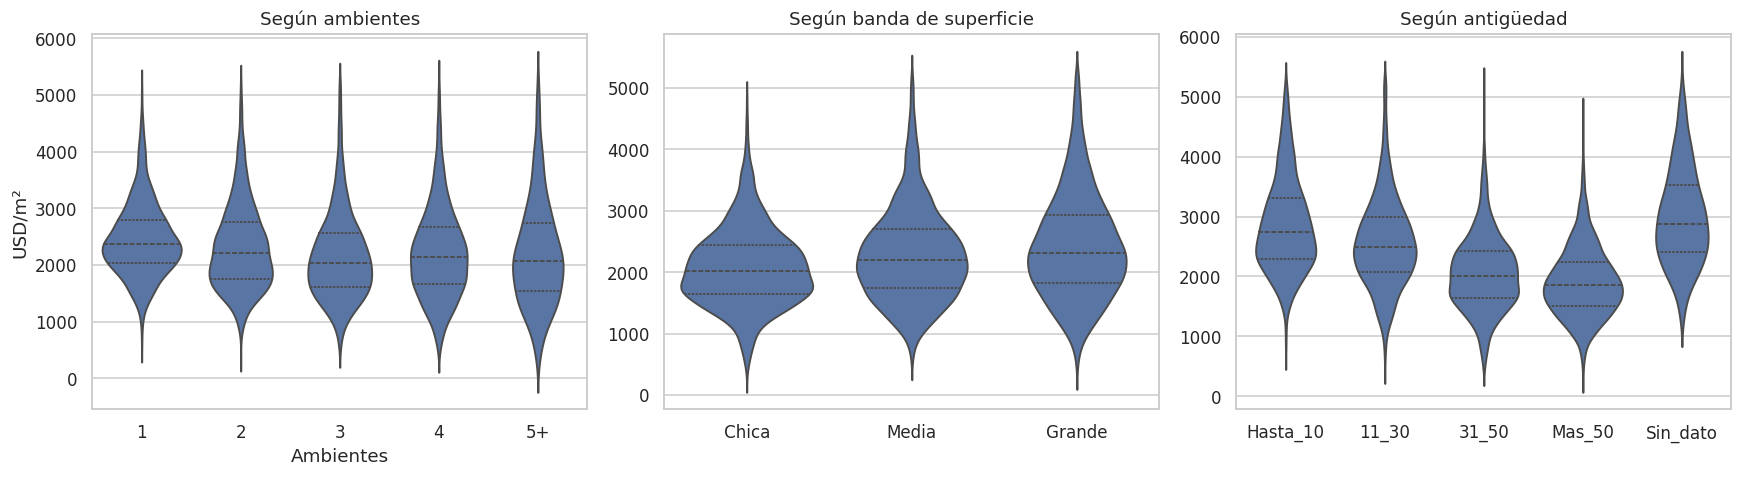

Los gráficos excluyen el 1% de avisos con mayor USD/m² para mejorar la lectura.


In [ ]:
# 3.2 USD/M² SEGÚN AMBIENTES, SUPERFICIE Y ANTIGÜEDAD

fig, ejes = plt.subplots(1, 3, figsize=(16, 4.5))
recorte = df["USD_m2_Homogeneizado"].quantile(0.99)
datos = df[df["USD_m2_Homogeneizado"] <= recorte]

sns.violinplot(data=datos, x="Ambientes_Grupo", y="USD_m2_Homogeneizado",
               order=orden_amb, inner="quartile", ax=ejes[0])
ejes[0].set(title="Según ambientes", xlabel="Ambientes", ylabel="USD/m²")
sns.violinplot(data=datos, x="Banda_Superficie", y="USD_m2_Homogeneizado",
               order=["Chica", "Media", "Grande"], inner="quartile", ax=ejes[1])
ejes[1].set(title="Según banda de superficie", xlabel="", ylabel="")
sns.violinplot(data=datos, x="Banda_Antiguedad", y="USD_m2_Homogeneizado",
               order=orden_ant, inner="quartile", ax=ejes[2])
ejes[2].set(title="Según antigüedad", xlabel="", ylabel="")
plt.tight_layout()
plt.show()
print("Los gráficos excluyen el 1% de avisos con mayor USD/m² para mejorar la lectura.")

**Asociación con la superficie y la antigüedad.** Se mide con el coeficiente de correlación de Spearman, que capta relaciones monótonas sin suponer linealidad ni normalidad. H0: no hay asociación monótona entre las variables (ρ = 0). H1: existe asociación (ρ ≠ 0).

In [ ]:
# 3.3 CORRELACIÓN DE SPEARMAN

filas = []
for var in ["Superficie_Homogeneizada_m2", "Antiguedad", "Ambientes", "Expensas_por_m2"]:
    datos_par = df[["USD_m2_Homogeneizado", var]].dropna()
    rho, p = stats.spearmanr(datos_par["USD_m2_Homogeneizado"], datos_par[var])
    filas.append({"Variable": var, "N": len(datos_par), "Rho de Spearman": round(rho, 3),
                  "p-valor": p, "Rechaza H0 (5%)": p < 0.05})
display(pd.DataFrame(filas).set_index("Variable"))

,N,Rho de Spearman,p-valor,Rechaza H0 (5%)
Variable,,,,
Superficie_Homogeneizada_m2,9499,-0.02,0.02,True
Antiguedad,9177,-0.48,0.00,True
Ambientes,9499,-0.12,0.00,True
Expensas_por_m2,8517,0.41,0.00,True


**Resultado.** La antigüedad es la variable física con mayor asociación con el precio por m²: la correlación de Spearman es de −0,48, lo que indica que los edificios más antiguos se publican a un precio por m² sistemáticamente menor. La cantidad de ambientes tiene una asociación negativa pero débil (−0,12), y la superficie prácticamente no se asocia con el precio por m² en el conjunto de la ciudad (−0,02). Aunque esta última es estadísticamente significativa, su magnitud es despreciable: con casi 9.500 observaciones, incluso asociaciones mínimas resultan significativas, por lo que hay que mirar el tamaño del coeficiente y no solo el p-valor.

Las expensas por m² tienen una correlación positiva moderada con el precio por m² (0,41), coherente con que los edificios de mayor categoría tienen más servicios. Estos resultados justifican incluir la antigüedad en la definición de los grupos de comparables, como se hace en el benchmark.

## 4. Estado de la oferta

**Pregunta descriptiva 3:** ¿qué proporción de la oferta necesita obra, está en buen estado, reciclada o no informa su estado? ¿Esa composición cambia entre comunas?

Para evaluar si la composición depende de la zona se aplica un test chi-cuadrado de independencia. H0: el estado de la propiedad es independiente de la comuna. H1: la composición por estado difiere entre comunas.

Distribución general (%):


,%
Estado_Propiedad,
Necesita_obra,4.60
Reciclada_refaccionada,10.30
Buen_estado,21.60
Sin_clasificar,63.50


Chi-cuadrado = 277.4, gl = 42, p-valor = 1.95e-36, rechaza H0 (5%): True


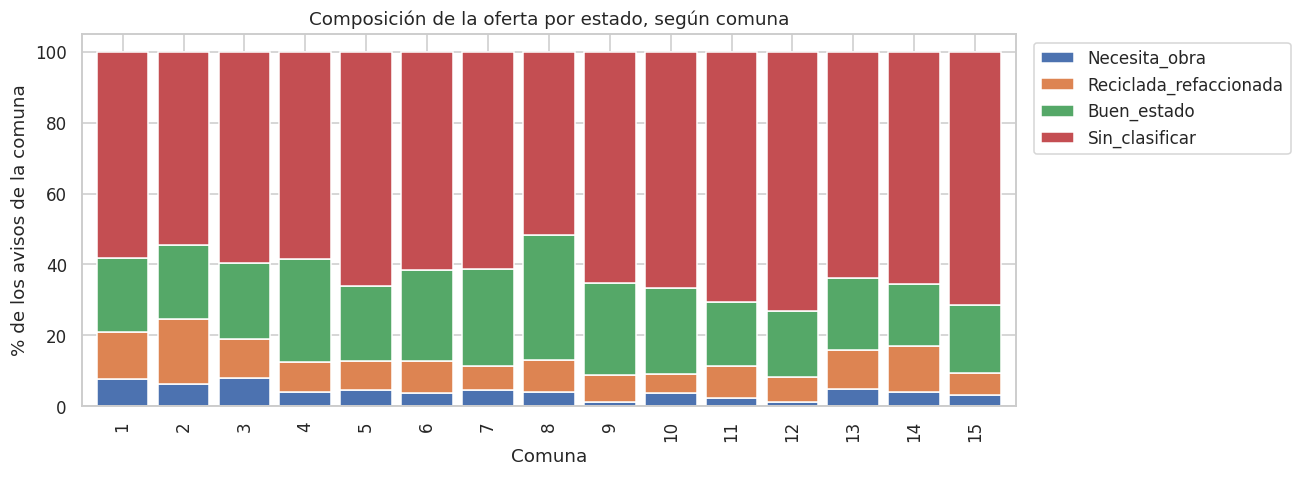

In [ ]:
# 4.1 ESTADO DE LA PROPIEDAD POR COMUNA

orden_estado = ["Necesita_obra", "Reciclada_refaccionada", "Buen_estado", "Sin_clasificar"]
print("Distribución general (%):")
display((df["Estado_Propiedad"].value_counts(normalize=True) * 100).reindex(orden_estado).round(1).to_frame("%"))

tabla_estado = pd.crosstab(df["Comuna"], df["Estado_Propiedad"])[orden_estado]
chi2, p, gl, _ = stats.chi2_contingency(tabla_estado)
print(f"Chi-cuadrado = {chi2:.1f}, gl = {gl}, p-valor = {p:.2e}, rechaza H0 (5%): {p < 0.05}")

(pd.crosstab(df["Comuna"], df["Estado_Propiedad"], normalize="index")[orden_estado] * 100).plot(
    kind="bar", stacked=True, figsize=(12, 4.5), width=0.85)
plt.title("Composición de la oferta por estado, según comuna")
plt.ylabel("% de los avisos de la comuna")
plt.xlabel("Comuna")
plt.legend(title="", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Resultado.** El 63,5% de la oferta no informa el estado del inmueble, el 21,6% declara buen estado, el 10,3% está reciclado y el 4,6% necesita obra. El test chi-cuadrado rechaza la independencia entre el estado y la comuna (p < 0,001): la composición de la oferta por estado no es la misma en toda la ciudad. Esto implica que el segmento de unidades que necesitan obra no está distribuido de manera uniforme, y que las oportunidades de flipping se concentrarán en algunas zonas más que en otras (ver sección 9).

## 5. Descuento por condición (H1)

**Preguntas:** ¿qué diferencia de USD/m² hay entre los departamentos que necesitan obra y los reciclados? (descriptiva 2) ¿Ese descuento se mantiene al comparar con propiedades similares? (H1)

La comparación directa de precios mezcla el efecto del estado con el de la ubicación y el tamaño. Por eso se analiza en dos niveles:

1. **Comparación directa** del USD/m² entre categorías de estado.
2. **Comparación controlada**, usando el precio relativo al benchmark de comparables (que ya compara cada aviso con propiedades de su barrio, ambientes, superficie y antigüedad).

En ambos casos se aplica el test U de Mann-Whitney. H0: las distribuciones de ambos grupos son iguales. H1 (unilateral): las propiedades que necesitan obra tienen un USD/m² (o un precio relativo) menor.

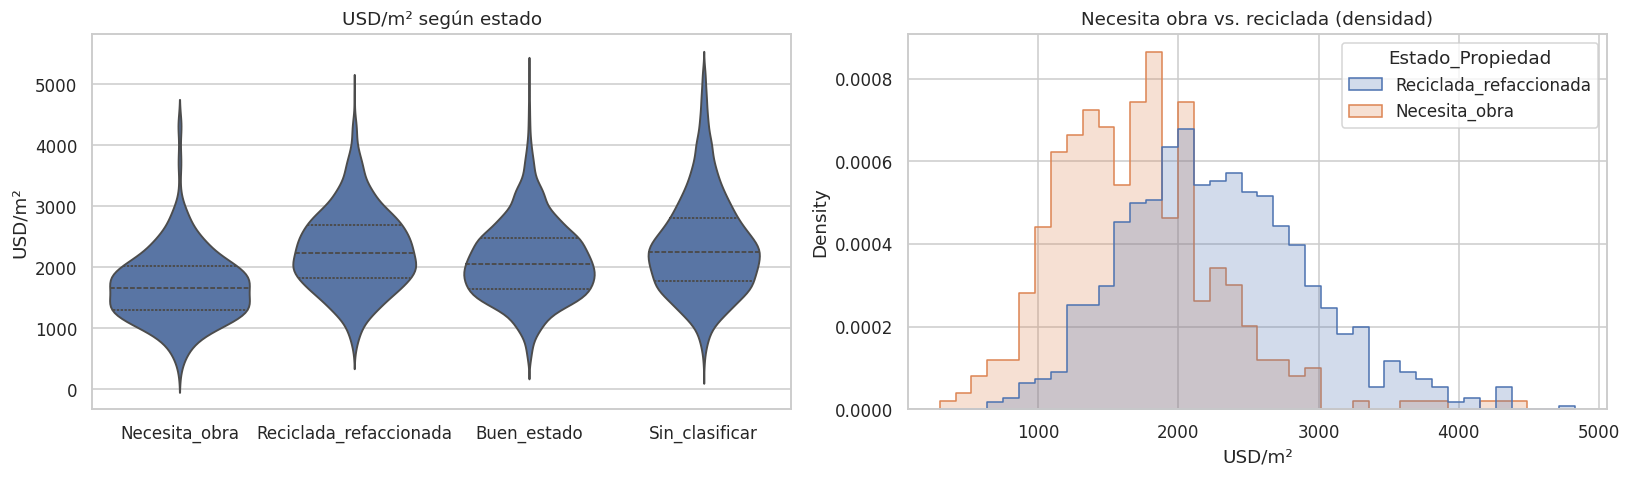

,Comparación directa
N Necesita obra,439
N Reciclada,977
Mediana Necesita obra,"1,665.43"
Mediana Reciclada,"2,232.21"
Diferencia de medianas (%),-25.40
Estadístico U,"104,283.00"
p-valor,0.00
Rechaza H0 (5%),True


In [ ]:
# 5.1 COMPARACIÓN DIRECTA DEL USD/M² POR ESTADO

fig, ejes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.violinplot(data=datos, x="Estado_Propiedad", y="USD_m2_Homogeneizado",
               order=orden_estado, inner="quartile", ax=ejes[0])
ejes[0].set(title="USD/m² según estado", xlabel="", ylabel="USD/m²")

comparacion = datos[datos["Estado_Propiedad"].isin(["Necesita_obra", "Reciclada_refaccionada"])]
sns.histplot(data=comparacion, x="USD_m2_Homogeneizado", hue="Estado_Propiedad",
             stat="density", common_norm=False, element="step", bins=40, ax=ejes[1])
ejes[1].set(title="Necesita obra vs. reciclada (densidad)", xlabel="USD/m²")
plt.tight_layout()
plt.show()

usd = df["USD_m2_Homogeneizado"]
display(test_mann_whitney(usd[df["Estado_Propiedad"].eq("Necesita_obra")],
                          usd[df["Estado_Propiedad"].eq("Reciclada_refaccionada")],
                          "Necesita obra", "Reciclada", alternativa="less").to_frame("Comparación directa"))

**Resultado.** En la comparación directa, la mediana del USD/m² de las unidades que necesitan obra (USD 1.665) es 25,4% menor que la de las recicladas (USD 2.232). El test de Mann-Whitney rechaza la hipótesis nula (p < 0,001): las unidades que necesitan obra tienden a publicarse a un precio por m² menor. Sin embargo, esta comparación no controla la ubicación ni el tamaño: la diferencia podría deberse en parte a que las unidades que necesitan obra se concentran en otras zonas o tipos de edificio.

,Precio relativo al benchmark (%)
N Necesita obra,435
N Buen estado o reciclada,3010
Mediana Necesita obra,-17.41
Mediana Buen estado o reciclada,0.04
Diferencia de medianas (puntos),-17.50
Estadístico U,"331,450.50"
p-valor,0.00
Rechaza H0 (5%),True


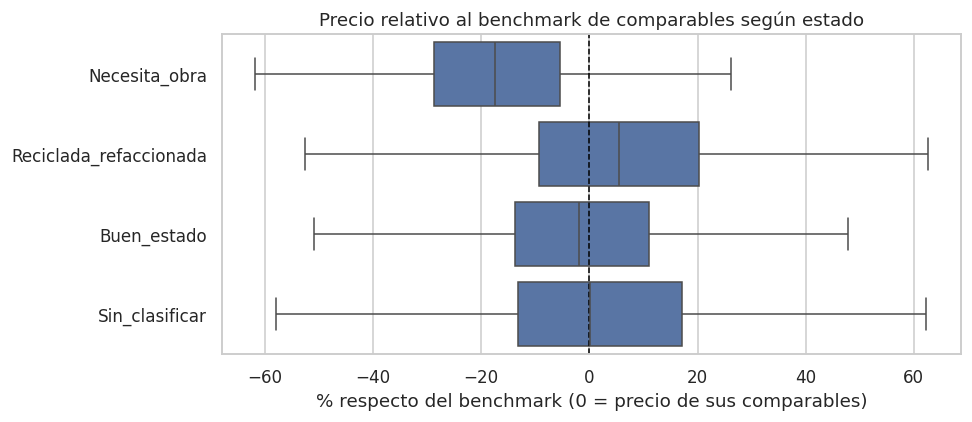

In [ ]:
# 5.2 COMPARACIÓN CONTROLADA: PRECIO RELATIVO AL BENCHMARK

relativo = df["Precio_Relativo_pct"]
display(test_mann_whitney(relativo[df["Estado_Propiedad"].eq("Necesita_obra")],
                          relativo[df["Estado_Agrupado"].eq("Buen_o_reciclada")],
                          "Necesita obra", "Buen estado o reciclada",
                          alternativa="less", diferencia="puntos").to_frame("Precio relativo al benchmark (%)"))

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df[df["Precio_Relativo_pct"].between(-80, 120)], x="Precio_Relativo_pct",
            y="Estado_Propiedad", order=orden_estado, showfliers=False, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set(title="Precio relativo al benchmark de comparables según estado",
       xlabel="% respecto del benchmark (0 = precio de sus comparables)", ylabel="")
plt.tight_layout()
plt.show()

**Resultado.** La comparación controlada confirma el descuento. Medido respecto del benchmark de sus comparables (mismo barrio, ambientes, superficie y antigüedad), el precio de las unidades que necesitan obra se ubica en la mediana un 17,4% por debajo de su benchmark, mientras que el de las unidades en buen estado o recicladas coincide con él (0,0%). La diferencia de 17,5 puntos es significativa (Mann-Whitney, p < 0,001).

Esto constituye **evidencia preliminar a favor de H1**: el descuento por necesitar obra se mantiene al comparar con propiedades similares de la misma zona. Además, permite separar los dos efectos: de los 25 puntos de diferencia directa, unos 17 se asocian al estado y el resto a diferencias de ubicación y tipo de unidad. La validación formal se realizará en la siguiente etapa, cuando también se valide manualmente la clasificación del estado.

**Pregunta diagnóstica 2:** ¿el descuento por necesitar obra es similar en todas las zonas? Se calcula el gap de estado por comuna (diferencia entre las medianas de USD/m² de reciclados y de unidades que necesitan obra, sobre la mediana de los reciclados) en las comunas con al menos 10 avisos de cada grupo. Además se aplica un test de Kruskal-Wallis al precio relativo de las unidades que necesitan obra entre comunas. H0: el precio relativo de las unidades que necesitan obra tiene la misma distribución en todas las comunas.

In [ ]:
# 5.3 GAP DE ESTADO POR COMUNA

medianas = (df[df["Estado_Propiedad"].isin(["Necesita_obra", "Reciclada_refaccionada"])]
            .groupby(["Comuna", "Estado_Propiedad"])["USD_m2_Homogeneizado"]
            .agg(["median", "count"]).unstack())
validas = (medianas[("count", "Necesita_obra")] >= 10) & (medianas[("count", "Reciclada_refaccionada")] >= 10)
gap_estado = ((medianas[("median", "Reciclada_refaccionada")] - medianas[("median", "Necesita_obra")])
              / medianas[("median", "Reciclada_refaccionada")] * 100)[validas].round(1)
print(f"Comunas con al menos 10 avisos en cada grupo: {validas.sum()}")
display(gap_estado.rename("Gap de estado (%)").to_frame())

print("Kruskal-Wallis del precio relativo de las unidades que necesitan obra entre comunas:")
display(test_kruskal(df[df["Estado_Propiedad"].eq("Necesita_obra")], "Comuna",
                     "Precio_Relativo_pct", min_n=10).to_frame("Resultado"))

Comunas con al menos 10 avisos en cada grupo: 12


,Gap de estado (%)
Comuna,
1,29.40
2,22.90
3,25.10
4,18.10
5,19.20
6,24.20
7,21.70
10,20.70
11,12.10


Kruskal-Wallis del precio relativo de las unidades que necesitan obra entre comunas:


,Resultado
Grupos comparados,12
Estadístico H,13.50
p-valor,0.26
Rechaza H0 (5%),False


**Resultado.** En las 12 comunas con suficientes casos, el gap de estado (descuento de las unidades que necesitan obra respecto de las recicladas) va del 12% en la comuna 11 al 29% en la comuna 1, y en la mayoría se ubica entre 18% y 25%. El test de Kruskal-Wallis no rechaza la hipótesis nula (p = 0,26): no hay evidencia de que el precio relativo de las unidades que necesitan obra difiera entre comunas.

Esto responde la pregunta diagnóstica 2: **el descuento por necesitar obra es similar en toda la ciudad**. Las diferencias entre comunas que muestra la tabla pueden atribuirse a la variabilidad muestral. Para el fondo, esto significa que el descuento no depende de la zona; lo que cambia entre zonas es el nivel de precio sobre el que se aplica, y con él el margen en dólares.

## 6. Dispersión de precios y oportunidades (H2)

**Pregunta diagnóstica 4:** ¿la dispersión del USD/m² dentro de grupos homogéneos permite identificar micromercados u oportunidades?

La dispersión se mide dentro de estratos homogéneos (barrio × ambientes × banda de superficie), no sobre el barrio completo, porque en el barrio completo la dispersión refleja en gran parte diferencias de producto. Primero se evalúa si la dispersión difiere entre barrios con el test de Levene centrado en la mediana (Brown-Forsythe), robusto a la falta de normalidad. H0: la variabilidad del USD/m² es la misma en todos los barrios. Luego se analiza si los estratos más dispersos concentran más oportunidades y si esas oportunidades tienen más indicadores de posibles errores de carga.

In [ ]:
# 6.1 ¿LA DISPERSIÓN DIFIERE ENTRE BARRIOS?

grupos_barrio = [g["USD_m2_Homogeneizado"].values for _, g in df.groupby("Barrio_Oficial")
                 if len(g) >= 30]
estadistico, p = stats.levene(*grupos_barrio, center="median")
print(f"Levene (Brown-Forsythe): W = {estadistico:.2f}, p-valor = {p:.2e}, "
      f"rechaza H0 (5%): {p < 0.05}, barrios comparados: {len(grupos_barrio)}")

print("\nBarrios con mayor y menor dispersión relativa (IQR / mediana):")
display(tabla_barrios.sort_values("Dispersion_relativa", ascending=False)
        .iloc[np.r_[0:5, -5:0]][["N", "Mediana", "Dispersion_relativa"]])

Levene (Brown-Forsythe): W = 13.91, p-valor = 2.28e-93, rechaza H0 (5%): True, barrios comparados: 43

Barrios con mayor y menor dispersión relativa (IQR / mediana):


,N,Mediana,Dispersion_relativa
Barrio_Oficial,,,
Parque Avellaneda,32,"1,454.64",0.49
Villa Ortuzar,106,"2,751.24",0.49
Constitucion,189,"1,390.91",0.49
Paternal,36,"1,830.10",0.47
Villa Lugano,101,916.67,0.42
Boedo,123,"1,851.85",0.27
Villa Luro,74,"1,900.00",0.26
Puerto Madero,43,"5,110.48",0.26
Coghlan,64,"2,539.74",0.23


**Resultado.** El test de Levene (Brown-Forsythe) rechaza que la variabilidad del USD/m² sea igual en todos los barrios (p < 0,001). Los barrios más dispersos son Villa Ortúzar, Constitución, Parque Avellaneda y La Paternal, con una dispersión relativa cercana a 0,5; los menos dispersos, Parque Chas, Coghlan y Puerto Madero, alrededor de 0,2. Esto confirma la primera parte de H2: la dispersión del precio no es homogénea entre barrios.

In [ ]:
# 6.2 DISPERSIÓN DENTRO DE ESTRATOS HOMOGÉNEOS Y OPORTUNIDADES

estrato = ["Barrio_Oficial", "Ambientes_Grupo", "Banda_Superficie"]
es_barata = df["Clasificacion_Oportunidad"].str.startswith("Barata")
requiere_verif = df["Clasificacion_Oportunidad"].eq("Barata_requiere_verificacion")

estratos = (
    df.assign(Barata=es_barata, Verificacion=requiere_verif)
    .groupby(estrato, observed=True)
    .agg(N=("USD_m2_Homogeneizado", "size"),
         Mediana=("USD_m2_Homogeneizado", "median"),
         IQR=("USD_m2_Homogeneizado", lambda x: x.quantile(0.75) - x.quantile(0.25)),
         Pct_baratas=("Barata", "mean"),
         Baratas=("Barata", "sum"),
         Verificacion=("Verificacion", "sum"))
)
estratos = estratos[estratos["N"] >= 10].copy()
estratos["Dispersion_relativa"] = estratos["IQR"] / estratos["Mediana"]
estratos["Quintil_dispersion"] = pd.qcut(estratos["Dispersion_relativa"], 5,
                                         labels=["Q1 (menos disperso)", "Q2", "Q3", "Q4", "Q5 (más disperso)"])

rho, p = stats.spearmanr(estratos["Dispersion_relativa"], estratos["Pct_baratas"])
print(f"Estratos con al menos 10 avisos: {len(estratos)}")
print(f"Spearman dispersión vs. % de baratas: rho = {rho:.3f}, p-valor = {p:.2e}")

resumen_quintiles = estratos.groupby("Quintil_dispersion", observed=True).agg(
    Estratos=("N", "size"), Avisos=("N", "sum"), Baratas=("Baratas", "sum"),
    Requieren_verificacion=("Verificacion", "sum"))
resumen_quintiles["% baratas"] = (resumen_quintiles["Baratas"] / resumen_quintiles["Avisos"] * 100).round(1)
resumen_quintiles["% de baratas que requieren verificación"] = (
    resumen_quintiles["Requieren_verificacion"] / resumen_quintiles["Baratas"] * 100).round(1)
display(resumen_quintiles)

Estratos con al menos 10 avisos: 289
Spearman dispersión vs. % de baratas: rho = 0.477, p-valor = 8.51e-18


,Estratos,Avisos,Baratas,Requieren_verificacion,% baratas,% de baratas que requieren verificación
Quintil_dispersion,,,,,,
Q1 (menos disperso),58,1052,37,2,3.50,5.40
Q2,58,1847,89,11,4.80,12.40
Q3,57,1571,128,14,8.10,10.90
Q4,58,1864,185,22,9.90,11.90
Q5 (más disperso),58,1884,220,29,11.70,13.20


**Resultado.** Dentro de los 289 estratos homogéneos (barrio, ambientes y superficie) con al menos 10 avisos, la dispersión se asocia positivamente con la proporción de propiedades baratas (Spearman ρ = 0,48, p < 0,001). El porcentaje de baratas pasa del 3,5% en el quintil de estratos menos dispersos al 11,7% en el más disperso.

Pero esta relación tiene dos lecturas, y H2 lo anticipaba. Por un lado, es en parte mecánica: cuanto más dispersos son los precios de un grupo, más propiedades se alejan de su mediana, y más superan el umbral de gap. Por otro lado, la proporción de baratas que **requieren verificación** por indicadores de posible error de carga también aumenta con la dispersión: del 5,4% en el quintil menos disperso al 13,2% en el más disperso. Una parte de la dispersión, por lo tanto, se explica por problemas de calidad de los datos y no por oportunidades.

La evidencia es **parcialmente favorable a H2**: los estratos dispersos concentran más oportunidades, pero también más casos dudosos. Por eso las oportunidades de esos estratos requieren una revisión más cuidadosa antes de recomendarlas.

## 7. Amenities, características y precio

**Pregunta descriptiva 4:** ¿qué características y amenities aparecen con mayor frecuencia en cada segmento de precio?

**Pregunta diagnóstica 3:** ¿qué relación tienen con el precio dentro de segmentos comparables?

Para la primera se compara la frecuencia de cada característica entre cuartiles de USD/m². Para la segunda se usa el precio relativo al benchmark: como el benchmark ya controla barrio, ambientes, superficie y antigüedad, la diferencia de precio relativo entre avisos con y sin una característica aproxima su "premio" dentro de segmentos comparables. Se aplica Mann-Whitney bilateral. H0: el precio relativo es igual con y sin la característica.

Cuartil_USD_m2,Q1 (más baratos),Q2,Q3,Q4 (más caros)
Cochera_Incluida,8.30,18.20,29.10,50.70
Balcon,52.70,62.10,74.80,83.90
Terraza,17.90,20.90,26.00,37.90
Patio,17.20,16.10,13.60,9.90
Ascensor,42.90,48.30,56.00,61.80
Baulera,12.30,16.90,18.80,25.80
Pileta,3.20,5.90,14.70,42.40
SUM,2.10,8.20,16.40,40.40
Gimnasio,0.50,2.60,5.60,25.80
Laundry,1.80,5.10,11.80,28.20


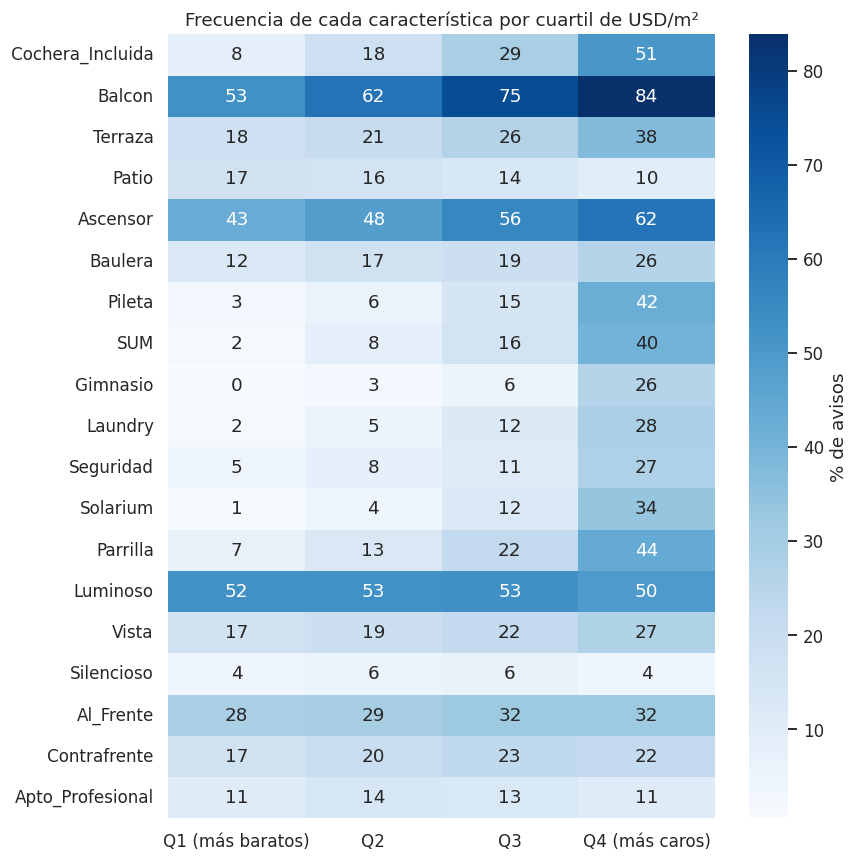

In [ ]:
# 7.1 FRECUENCIA DE CARACTERÍSTICAS POR CUARTIL DE PRECIO

caracteristicas = ["Cochera_Incluida", "Balcon", "Terraza", "Patio", "Ascensor", "Baulera",
                   "Pileta", "SUM", "Gimnasio", "Laundry", "Seguridad", "Solarium", "Parrilla",
                   "Luminoso", "Vista", "Silencioso", "Al_Frente", "Contrafrente", "Apto_Profesional"]

df["Cuartil_USD_m2"] = pd.qcut(df["USD_m2_Homogeneizado"], 4,
                               labels=["Q1 (más baratos)", "Q2", "Q3", "Q4 (más caros)"])
frecuencias = (df.groupby("Cuartil_USD_m2", observed=True)[caracteristicas].mean() * 100).T.round(1)
display(frecuencias)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(frecuencias, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% de avisos"}, ax=ax)
ax.set(title="Frecuencia de cada característica por cuartil de USD/m²", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

**Resultado.** Las amenities del edificio son las características que más diferencian a los segmentos de precio. Entre el cuartil más barato y el más caro de USD/m², la proporción de avisos con pileta pasa del 3% al 42%; con SUM, del 2% al 40%; con solarium, del 1% al 34%; y con gimnasio, del 0,5% al 26%. La cochera incluida pasa del 8% al 51%, y la parrilla, del 7% al 44%. En el segmento más caro también son más frecuentes el balcón (84% contra 53%), la terraza (38% contra 18%) y la baulera (26% contra 12%).

El patio es la única característica que disminuye con el precio (del 17% al 10%), coherente con su asociación con unidades de planta baja o edificios antiguos. En cambio, las características que el anunciante declara en el texto casi no diferencian segmentos: la luminosidad se menciona en alrededor de la mitad de los avisos en todos los cuartiles, y lo mismo ocurre con la orientación, el silencio o el apto profesional. Son descripciones que se usan de manera generalizada y aportan poca información para distinguir el valor de una propiedad.

In [ ]:
# 7.2 PREMIO DE CADA CARACTERÍSTICA DENTRO DE SEGMENTOS COMPARABLES

premios = premio_por_variable(df[df["Precio_Relativo_pct"].notna()], caracteristicas, "Precio_Relativo_pct")
premios = premios.rename(columns={"Mediana con": "Precio relativo con (%)",
                                  "Mediana sin": "Precio relativo sin (%)",
                                  "Diferencia (puntos)": "Premio (puntos %)"})
display(premios)

,N con,Precio relativo con (%),Precio relativo sin (%),Premio (puntos %),p-valor,Rechaza H0 (5%)
Variable,,,,,,
Gimnasio,816,25.12,-1.83,26.95,0.00,True
Solarium,1211,16.52,-2.22,18.73,0.00,True
Pileta,1567,15.54,-2.67,18.21,0.00,True
SUM,1589,15.17,-2.70,17.88,0.00,True
Laundry,1107,14.53,-1.82,16.35,0.00,True
Seguridad,1203,13.76,-1.73,15.49,0.00,True
Cochera_Incluida,2500,11.02,-3.51,14.52,0.00,True
Parrilla,2023,9.68,-2.50,12.18,0.00,True
Balcon,6453,3.04,-7.12,10.16,0.00,True


**Resultado.** Las amenities del edificio son las características con mayor asociación con el precio dentro de segmentos comparables. Respecto del benchmark, los avisos con gimnasio se publican en la mediana 27 puntos más caros que los que no lo tienen; los que tienen solarium, pileta o SUM, entre 18 y 19 puntos más; y los que tienen laundry o seguridad, entre 15 y 16 puntos más. La cochera incluida se asocia con un premio de 14,5 puntos, la parrilla con 12 y el balcón con 10. Todas las diferencias son significativas (p < 0,001).

Las características de la unidad declaradas en el texto tienen un efecto mucho menor: vista y terraza, unos 5 puntos; luminosidad, al frente o contrafrente, menos de 1,5 puntos. El patio se asocia con un precio menor (−6,9 puntos), probablemente porque aparece con más frecuencia en unidades de planta baja.

Hay que interpretar estos "premios" con cautela: las amenities aparecen juntas (un edificio con pileta suele tener también gimnasio y SUM), por lo que no son aditivos, y en parte reflejan la categoría del edificio más que el valor de cada amenity. La conclusión más relevante para el proyecto es otra: como el benchmark no incluye las amenities, **una unidad sin amenities en un grupo donde la mayoría las tiene aparece como "barata" aunque no lo sea**. Incorporar la categoría del edificio a los comparables, por ejemplo con un índice de amenities, es un paso clave para la siguiente etapa, y puede reducir el error del benchmark.

## 8. Correlaciones entre variables

Se presenta la matriz de correlaciones de Spearman entre el precio por m², las variables físicas y las principales características, para identificar asociaciones relevantes y posibles redundancias entre variables antes de la etapa de modelado.

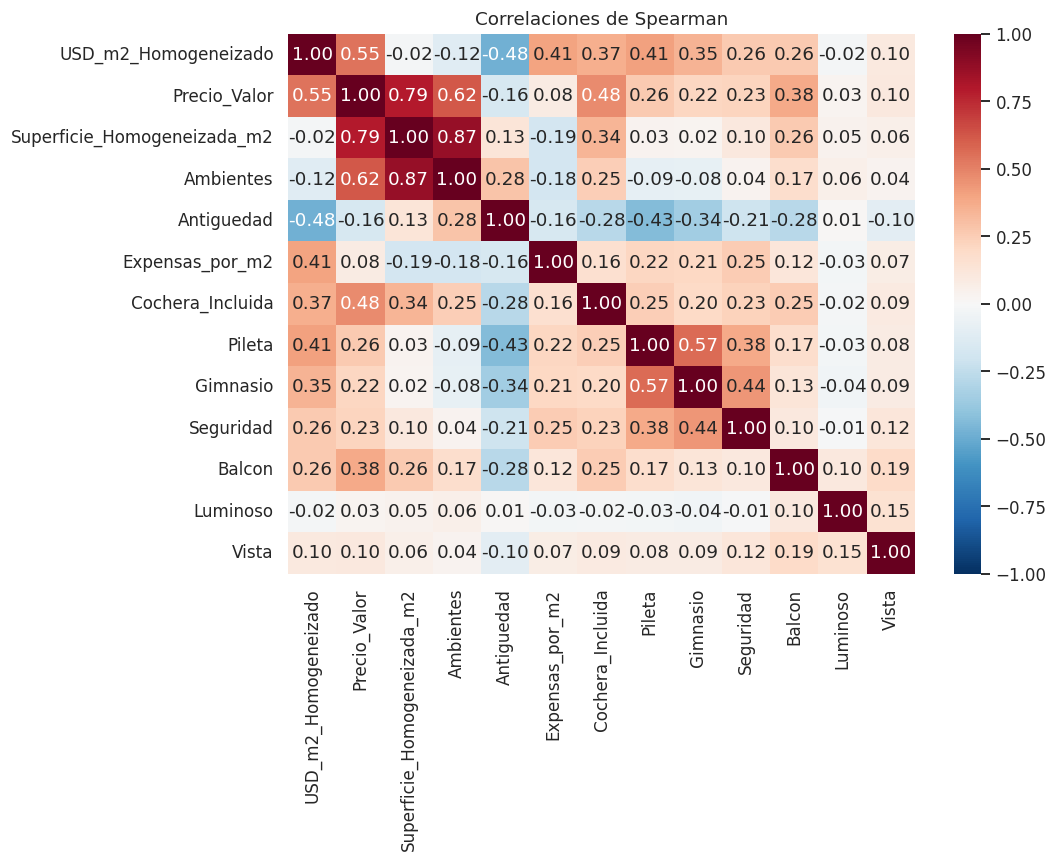

Los 10 pares de variables con correlación más fuerte:


,level_0,level_1,Rho
23,Superficie_Homogeneizada_m2,Ambientes,0.87
12,Precio_Valor,Superficie_Homogeneizada_m2,0.79
13,Precio_Valor,Ambientes,0.62
63,Pileta,Gimnasio,0.57
0,USD_m2_Homogeneizado,Precio_Valor,0.55
3,USD_m2_Homogeneizado,Antiguedad,-0.48
16,Precio_Valor,Cochera_Incluida,0.48
68,Gimnasio,Seguridad,0.44
44,Antiguedad,Pileta,-0.43
6,USD_m2_Homogeneizado,Pileta,0.41


In [ ]:
# 8. MATRIZ DE CORRELACIONES (SPEARMAN)

variables_corr = ["USD_m2_Homogeneizado", "Precio_Valor", "Superficie_Homogeneizada_m2", "Ambientes",
                  "Antiguedad", "Expensas_por_m2", "Cochera_Incluida", "Pileta", "Gimnasio",
                  "Seguridad", "Balcon", "Luminoso", "Vista"]
matriz = df[variables_corr].astype(float).corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set(title="Correlaciones de Spearman")
plt.tight_layout()
plt.show()

# Pares de variables con correlación más fuerte (en valor absoluto)
pares = (matriz.where(np.triu(np.ones(matriz.shape, dtype=bool), k=1)).stack()
         .rename("Rho").reset_index())
pares = pares.reindex(pares["Rho"].abs().sort_values(ascending=False).index).head(10)
print("Los 10 pares de variables con correlación más fuerte:")
display(pares.round(2))

**Resultado.** Las correlaciones más fuertes muestran tres grupos de variables relacionadas:

- **Tamaño:** la superficie y la cantidad de ambientes están muy correlacionadas (ρ = 0,87), y ambas se asocian con el precio total (0,79 y 0,62). Miden en gran parte lo mismo, lo que hay que considerar para no duplicar información en etapas de modelado.
- **Categoría del edificio:** las amenities aparecen juntas (pileta y gimnasio, ρ = 0,57; gimnasio y seguridad, 0,44) y se asocian negativamente con la antigüedad (pileta, −0,43): son propias de edificios más nuevos. Esto confirma que el "premio" de cada amenity estimado en la sección 7.2 refleja en gran parte la categoría del edificio, y no el valor individual de cada una.
- **Precio por m²:** se asocia con la antigüedad (−0,48) y con las amenities (pileta, 0,41).

Estas redundancias justifican, para la siguiente etapa, resumir las amenities en un índice sintético de categoría del edificio mediante reducción de dimensionalidad, en lugar de usarlas por separado.

## 9. Distribución espacial

**Pregunta:** ¿cómo se distribuyen en el territorio el precio por m², las propiedades baratas y las que necesitan obra?

Se grafican los avisos según sus coordenadas, sobre los límites oficiales de los barrios. Los tres avisos con coordenadas inválidas se excluyen de los mapas.

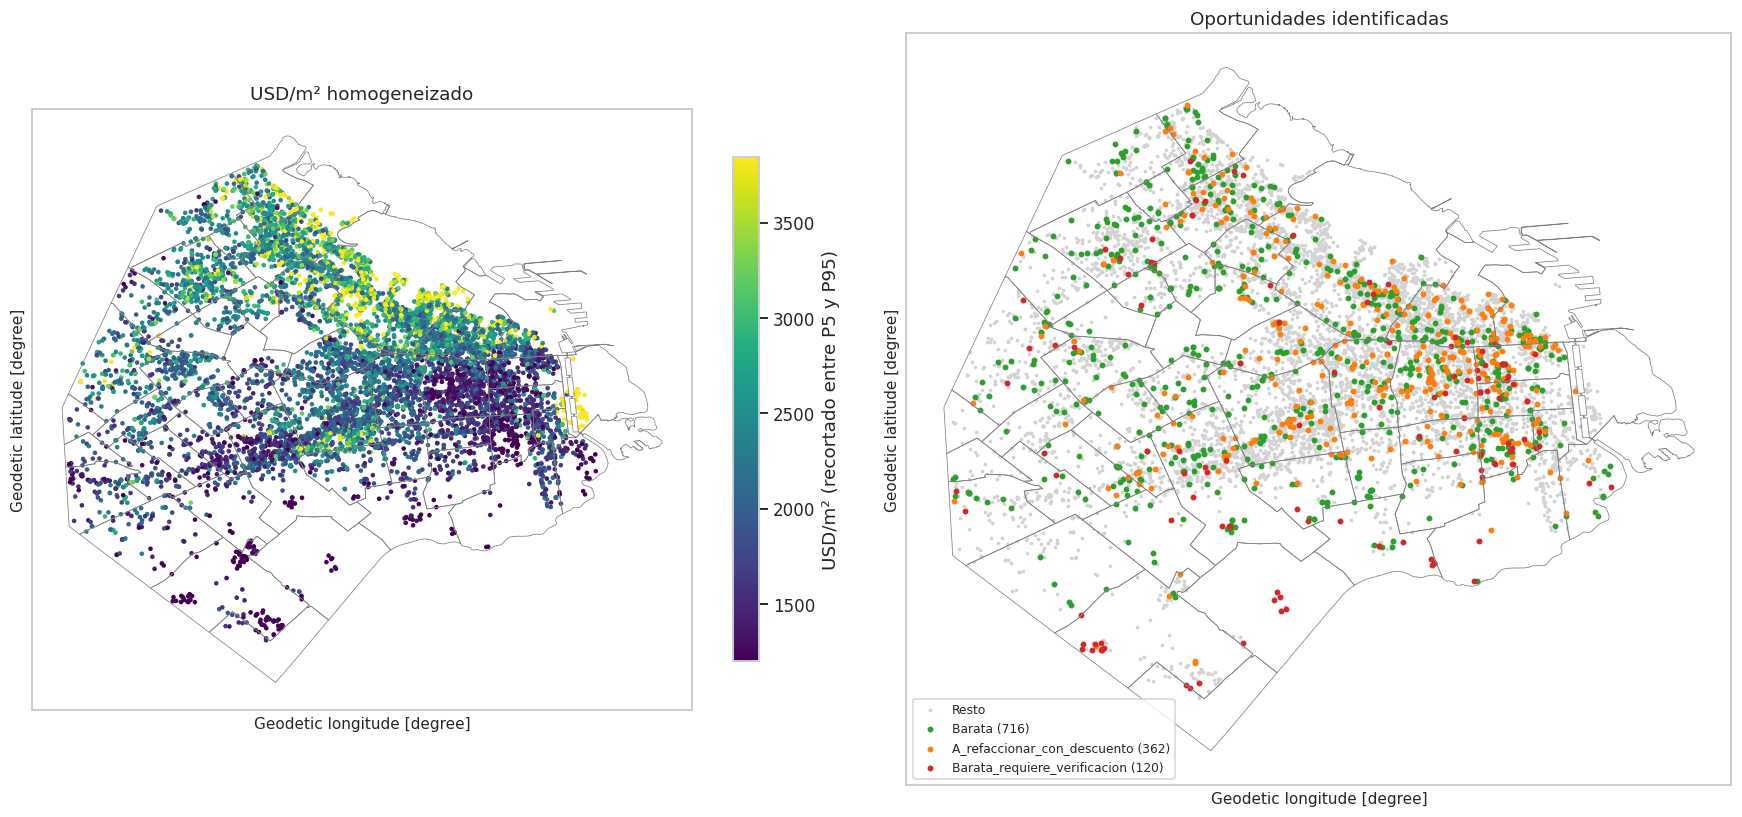

In [ ]:
# 9. MAPAS DE LA OFERTA

import geopandas as gpd

import requests

RUTA_BARRIOS = Path("data/external/barrios_caba.geojson")
URL_BARRIOS = ("https://cdn.buenosaires.gob.ar/datosabiertos/datasets/"
               "innovacion-transformacion-digital/barrios/barrios.geojson")
try:
    if not RUTA_BARRIOS.exists():
        RUTA_BARRIOS.parent.mkdir(parents=True, exist_ok=True)
        respuesta = requests.get(URL_BARRIOS, timeout=60, headers={"User-Agent": "Mozilla/5.0"})
        respuesta.raise_for_status()
        RUTA_BARRIOS.write_bytes(respuesta.content)
    barrios = gpd.read_file(RUTA_BARRIOS)
except Exception:
    barrios = None
    print("No se pudieron cargar los límites de barrios; los mapas se muestran sin ellos.")

geo = df.dropna(subset=["Latitud", "Longitud"])
fig, ejes = plt.subplots(1, 2, figsize=(16, 8))

for ax in ejes:
    if barrios is not None:
        barrios.boundary.plot(ax=ax, color="grey", linewidth=0.5)

limite = geo["USD_m2_Homogeneizado"].quantile([0.05, 0.95])
puntos = ejes[0].scatter(geo["Longitud"], geo["Latitud"], s=4, cmap="viridis",
                         c=geo["USD_m2_Homogeneizado"].clip(*limite))
fig.colorbar(puntos, ax=ejes[0], shrink=0.6, label="USD/m² (recortado entre P5 y P95)")
ejes[0].set(title="USD/m² homogeneizado")

ejes[1].scatter(geo["Longitud"], geo["Latitud"], s=2, color="lightgrey", label="Resto")
for categoria, color in [("Barata", "tab:green"), ("A_refaccionar_con_descuento", "tab:orange"),
                         ("Barata_requiere_verificacion", "tab:red")]:
    sub = geo[geo["Clasificacion_Oportunidad"].eq(categoria)]
    ejes[1].scatter(sub["Longitud"], sub["Latitud"], s=8, color=color, label=f"{categoria} ({len(sub)})")
ejes[1].set(title="Oportunidades identificadas")
ejes[1].legend(loc="lower left", fontsize=8)

for ax in ejes:
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
# 9.1 OPORTUNIDADES POR COMUNA

oportunidades_comuna = pd.crosstab(df["Comuna"], df["Clasificacion_Oportunidad"], margins=True)
oportunidades_comuna["% baratas"] = (
    (oportunidades_comuna.get("Barata", 0) + oportunidades_comuna.get("Barata_requiere_verificacion", 0))
    / oportunidades_comuna["All"] * 100).round(1)
display(oportunidades_comuna)

Clasificacion_Oportunidad,A_refaccionar_con_descuento,Barata,Barata_requiere_verificacion,Precio_de_mercado,Sin_benchmark,All,% baratas
Comuna,,,,,,,
1,72,92,29,880,0,1073,11.30
2,34,42,4,574,0,654,7.00
3,54,39,7,698,0,798,5.80
4,10,28,13,226,5,282,14.50
5,23,41,3,609,10,686,6.40
6,27,38,1,757,0,823,4.70
7,18,54,11,494,0,577,11.30
8,4,2,18,91,9,124,16.10
9,2,21,4,153,1,181,13.80


**Resultado.** Las oportunidades se distribuyen de manera desigual. Las comunas con mayor proporción de propiedades baratas son la 8 (16,1%), la 4 (14,5%) y la 9 (13,8%), todas del sur y del oeste, mientras que la 14 (Palermo), la 6 (Caballito) y la 3 (Balvanera y San Cristóbal) tienen las menores proporciones (entre 4,7% y 6,2%).

El caso de la comuna 8 muestra la importancia del control de calidad: de sus 20 propiedades baratas, 18 requieren verificación. Es una zona con precios por m² muy bajos respecto del resto de la ciudad, por lo que sus avisos quedan marcados como valores atípicos en la detección global. Esto confirma una limitación señalada en la limpieza: la detección de outliers sobre el conjunto de la ciudad marca como "atípicos" a los segmentos de menor precio, y no solo a los errores.

Las unidades a refaccionar con descuento se concentran en la comuna 1 (72), seguida por la 3, y por la 13 y la 14 (36 cada una). Es decir, las oportunidades de flipping aparecen tanto en el centro como en los barrios de mayor valor del corredor norte.

## 10. Liquidez: avisos reservados o en negociación

La fuente no informa la fecha de publicación, por lo que no se puede medir el tiempo en el mercado con una sola captura (pregunta descriptiva 5). Como aproximación, el estado comercial de la publicación indica si un aviso tiene una operación en curso. Se analiza si las propiedades reservadas o en negociación se publican más baratas respecto de sus comparables que las activas, lo que sugeriría que el descuento acelera la venta. Test de Mann-Whitney bilateral. H0: el precio relativo de los avisos reservados o en negociación tiene la misma distribución que el de los activos.

In [ ]:
# 10. ESTADO DE LA PUBLICACIÓN Y PRECIO RELATIVO

print("Estado de la publicación (%):")
display((df["Estado_Publicacion"].value_counts(normalize=True) * 100).round(1).to_frame("%"))

con_operacion = df["Estado_Publicacion"].isin(["reserved", "negotiation"])
display(test_mann_whitney(df.loc[con_operacion, "Precio_Relativo_pct"],
                          df.loc[df["Estado_Publicacion"].eq("active"), "Precio_Relativo_pct"],
                          "Reservado o en negociación", "Activo",
                          diferencia="puntos").to_frame("Precio relativo al benchmark (%)"))

print("Proporción de avisos con operación en curso según la clasificación de oportunidad (%):")
display((df.groupby("Clasificacion_Oportunidad")["Estado_Publicacion"]
         .apply(lambda s: s.isin(["reserved", "negotiation"]).mean() * 100).round(1)
         .to_frame("% reservados o en negociación")))

Estado de la publicación (%):


,%
Estado_Publicacion,
active,75.40
reserved,17.30
negotiation,7.30


,Precio relativo al benchmark (%)
N Reservado o en negociación,2330
N Activo,7120
Mediana Reservado o en negociación,-6.40
Mediana Activo,1.95
Diferencia de medianas (puntos),-8.40
Estadístico U,"6,399,502.50"
p-valor,0.00
Rechaza H0 (5%),True


Proporción de avisos con operación en curso según la clasificación de oportunidad (%):


,% reservados o en negociación
Clasificacion_Oportunidad,
A_refaccionar_con_descuento,40.10
Barata,34.10
Barata_requiere_verificacion,23.30
Precio_de_mercado,23.20
Sin_benchmark,12.20


**Resultado.** Los avisos reservados o en negociación (24,6% de la oferta) se publican, en la mediana, 6,4% por debajo de su benchmark, mientras que los activos se publican 2,0% por encima. La diferencia de 8,4 puntos es significativa (Mann-Whitney, p < 0,001). Además, la proporción de avisos con una operación en curso es mayor entre las propiedades baratas (34,1%) y las que necesitan obra con descuento (40,1%) que entre las de precio de mercado (23,2%).

Esto tiene dos implicancias para el fondo. Primero, las oportunidades que identifica el criterio coinciden con las que el mercado está tomando: el descuento relativo atrae demanda. Segundo, las oportunidades se agotan rápido, por lo que el valor del ranking depende de actualizarlo con frecuencia.

Un dato adicional respalda el control de calidad: entre las baratas que requieren verificación, la proporción con operación en curso (23,3%) es igual a la de las propiedades de precio de mercado. Si fueran oportunidades reales, deberían atraer más demanda; que no lo hagan sugiere que una parte de ellas son errores de carga y no descuentos genuinos.

## 11. Primera aproximación a las oportunidades de flipping (H3)

**Pregunta:** ¿en cuántas unidades que necesitan obra el valor post-obra estimado supera el precio de compra con un margen suficiente para cubrir los costos de la operación?

Los costos de obra todavía no están definidos, por lo que no se puede calcular el margen de flipping. Como aproximación preliminar, se compara el potencial bruto con los costos de transacción supuestos en el README (entre 6% y 8% de compra y entre 4% y 6% de venta, alrededor del 12% en total). Una propiedad cuyo potencial bruto no supera ese nivel no puede generar margen aun con un costo de obra nulo.

Unidades que necesitan obra con PER: 428


,Conservador,Base,Optimista
Potencial bruto mediano (%),10.20,23.10,39.60
% con potencial > 12%,46.70,67.80,85.00
Avisos con potencial > 12%,200.00,290.00,364.00


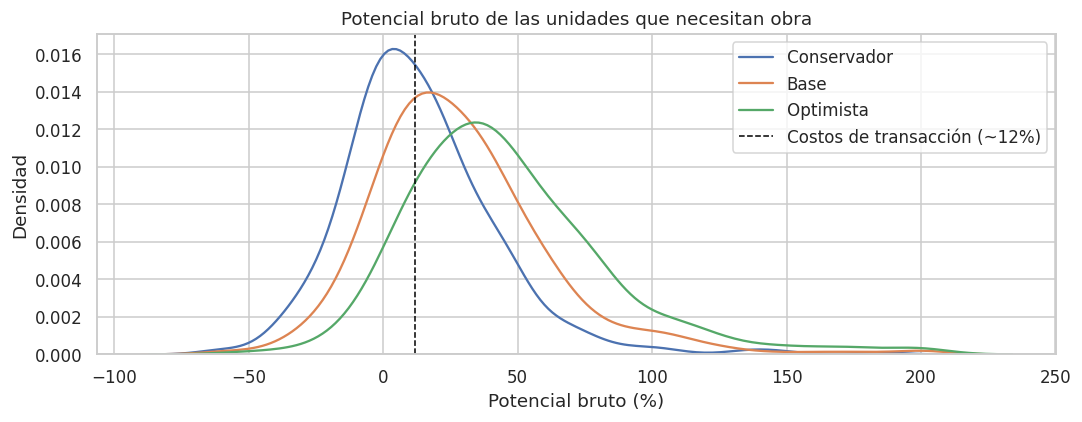

In [ ]:
# 11. POTENCIAL BRUTO FRENTE A LOS COSTOS DE TRANSACCIÓN

COSTOS_TRANSACCION_PCT = 12   # supuesto del README: compra 6-8% + venta 4-6%

obra = df[df["Estado_Propiedad"].eq("Necesita_obra") & df["PER_Base"].notna()]
escenarios = ["Conservador", "Base", "Optimista"]

resumen_h3 = pd.DataFrame({
    escenario: {
        "Potencial bruto mediano (%)": obra[f"Potencial_Bruto_{escenario}_pct"].median(),
        f"% con potencial > {COSTOS_TRANSACCION_PCT}%": (obra[f"Potencial_Bruto_{escenario}_pct"] > COSTOS_TRANSACCION_PCT).mean() * 100,
        f"Avisos con potencial > {COSTOS_TRANSACCION_PCT}%": int((obra[f"Potencial_Bruto_{escenario}_pct"] > COSTOS_TRANSACCION_PCT).sum()),
    } for escenario in escenarios
}).round(1)
print(f"Unidades que necesitan obra con PER: {len(obra)}")
display(resumen_h3)

fig, ax = plt.subplots(figsize=(10, 4))
for escenario in escenarios:
    sns.kdeplot(obra[f"Potencial_Bruto_{escenario}_pct"].clip(-60, 200), label=escenario, ax=ax)
ax.axvline(COSTOS_TRANSACCION_PCT, color="black", linestyle="--", linewidth=1,
           label=f"Costos de transacción (~{COSTOS_TRANSACCION_PCT}%)")
ax.set(title="Potencial bruto de las unidades que necesitan obra", xlabel="Potencial bruto (%)", ylabel="Densidad")
ax.legend()
plt.tight_layout()
plt.show()

**Resultado.** De las 428 unidades que necesitan obra con valor post-obra estimado, 290 (67,8%) tienen en el escenario base un potencial bruto superior al 12% estimado para los costos de compra y venta, y 200 (46,7%) lo superan en el escenario conservador. Esas son las candidatas a flipping: una propiedad cuyo potencial no supera los costos de transacción no puede generar margen ni con una obra de costo nulo.

Esto es **evidencia preliminar favorable a H3**, pero insuficiente para confirmarla: todavía falta descontar el costo de la obra, el costo de tenencia y las contingencias. Con una obra de nivel medio o integral, una parte importante de estas 290 unidades dejaría de tener margen positivo. La evaluación completa de H3 requiere definir los costos de refacción por nivel de obra (README, sección de costos).

## 12. Conclusiones del EDA

### Principales hallazgos

- **La ubicación es el principal determinante del precio.** El USD/m² mediano va de USD 917 en Villa Lugano a USD 5.110 en Puerto Madero, con un gradiente claro norte–sur. La antigüedad es la variable física con mayor asociación con el precio por m² (ρ = −0,48).
- **El descuento por necesitar obra es real y homogéneo.** Las unidades que necesitan obra se publican, en la mediana, 17,4% por debajo del benchmark de sus comparables, y ese descuento no difiere significativamente entre comunas.
- **Las amenities del edificio explican diferencias de precio que el benchmark no captura.** Gimnasio, pileta, SUM o seguridad se asocian con precios entre 15 y 27 puntos más altos que los comparables.
- **El mercado toma las oportunidades.** Los avisos reservados o en negociación están en promedio 8,4 puntos más baratos respecto de su benchmark que los activos, y las propiedades clasificadas como baratas tienen más operaciones en curso.
- **Hay candidatas a flipping.** 290 unidades que necesitan obra tienen un potencial bruto superior a los costos de transacción en el escenario base.

### Problemas de calidad detectados

- La detección global de outliers marca como atípicos a los segmentos de menor precio: en la comuna 8, 18 de las 20 propiedades baratas requieren verificación.
- Los estratos con mayor dispersión concentran también más casos con indicadores de posible error de carga.
- Las baratas que requieren verificación se comportan como propiedades de precio de mercado en términos de demanda, lo que sugiere que una parte son errores y no oportunidades.

### Decisiones adoptadas

- Se usaron estadísticos robustos y tests no paramétricos por la asimetría de las variables de precio.
- Las comparaciones de precio se hicieron también en términos relativos al benchmark, para controlar ubicación, tamaño y antigüedad.
- La dispersión se analizó dentro de estratos homogéneos y no sobre el barrio completo, siguiendo la reformulación de H2.

### Hipótesis

| Hipótesis | Evidencia preliminar |
| --- | --- |
| **H1.** Descuento por condición | **A favor.** Descuento de 17,4% respecto de comparables, significativo y similar entre comunas |
| **H2.** Dispersión condicional | **Parcialmente a favor.** La dispersión difiere entre barrios y los estratos dispersos concentran más oportunidades, pero también más casos dudosos |
| **H3.** Oportunidades de flipping | **Preliminarmente a favor.** 290 unidades superan los costos de transacción, pero falta descontar la obra y la tenencia |

### Hipótesis y preguntas que aún no pueden evaluarse

- **Permanencia en el mercado** (pregunta descriptiva 5): requiere capturas sucesivas del extractor.
- **H3 completa:** requiere los costos de refacción por nivel de obra.
- **Brecha entre precio publicado y precio de cierre:** requiere estadísticas de escrituras.

### Limitaciones

- Los precios son de publicación, no de cierre.
- `Estado_Propiedad` es una señal imperfecta, con validación manual pendiente.
- El benchmark tiene un error típico del 15% y no incorpora la categoría del edificio.
- La base proviene de una sola red inmobiliaria y de una única captura.

### Próximos pasos

- Incorporar la categoría del edificio a los comparables mediante un índice de amenities (reducción de dimensionalidad), y evaluar si reduce el error del benchmark.
- Completar la validación manual del estado.
- Definir los costos de obra para calcular el margen de flipping y evaluar H3.
- Realizar nuevas capturas del extractor para medir la permanencia en el mercado.
- Validar formalmente las hipótesis y avanzar con la segmentación en micromercados (clustering).